In [1]:
import numpy as np
import gpt as g
import matplotlib.pyplot as plt

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import gridspec

import scipy
import math
from scipy import special as sp
import time

SharedMemoryNone: SharedMemoryAllocate 1073741824 GPU implementation 
0SharedMemoryNone:  SharedMemoryNone.cc acceleratorAllocDevice 1073741824bytes at 0x305600000 for comms buffers 

__|__|__|__|__|__|__|__|__|__|__|__|__|__|__
__|__|__|__|__|__|__|__|__|__|__|__|__|__|__
__|_ |  |  |  |  |  |  |  |  |  |  |  | _|__
__|_                                    _|__
__|_   GGGG    RRRR    III    DDDD      _|__
__|_  G        R   R    I     D   D     _|__
__|_  G        R   R    I     D    D    _|__
__|_  G  GG    RRRR     I     D    D    _|__
__|_  G   G    R  R     I     D   D     _|__
__|_   GGGG    R   R   III    DDDD      _|__
__|_                                    _|__
__|__|__|__|__|__|__|__|__|__|__|__|__|__|__
__|__|__|__|__|__|__|__|__|__|__|__|__|__|__
  |  |  |  |  |  |  |  |  |  |  |  |  |  |  


Copyright (C) 2015 Peter Boyle, Azusa Yamaguchi, Guido Cossu, Antonin Portelli and other authors

This program is free software; you can redistribute it and/or modify
it under the term

In [2]:
class Jackknife:
    def __init__( self, len_data, binsize ):
        self.binsize = binsize
        self.nbins = math.floor( len_data/self.binsize )
        self.N = self.binsize * self.nbins
        self.jack_avg = []
        self.est = 0
        self.var_est = 0

    def set( self, func, list_of_data ):
        for i in range( self.nbins ):
            self.jack_avg.append( func( i, self.binsize, list_of_data ) )

    def do_it( self ):
        for i in range( 0, self.nbins ):
            self.est += self.jack_avg[i]
        self.est /= self.nbins

        for i in range( 0, self.nbins ):
            self.var_est += ( self.jack_avg[i] - self.est )**2
        self.var_est /= self.nbins
        self.var_est *= self.nbins -1

    def mean( self ):
        return self.est

    def var( self ):
        return self.var_est

    def err( self ):
        return np.sqrt(self.var_est)

def simple_mean(i, binsize, np_data):
    resmpld = np.delete(np_data, np.s_[i*binsize:(i+1)*binsize])
    return np.mean(resmpld)

def format_print(cen, err):
    for i in range(-50, 50):
        if 10**(-i+1)>=err>10**(-i):
            tmp=err*10**(i+1)
            return '{num:.{width}f}'.format(num=cen, width=i+1)+'('+str(round(tmp))+')'

def format_print_w_exact(exact, cen, err):
    for i in range(-50, 50):
        if 10**(-i+1)>=err>10**(-i):
            tmp=err*10**(i+1)
            return '{num:.{width}f}'.format(num=cen, width=i+1)+'('+str(round(tmp))+')'+': '+'{num:.{width}f}'.format(num=(exact-cen)/err, width=i+1)+' sigma'

In [3]:
def autocorrelation2(samples, separation, max_separation, binsize):
    mean = np.mean(samples)
    ACF = []
    err = []
    t = -1
    nskip = int(0)
    #binsize = 50
    
    for i in range(int(max_separation / separation)):
        t += separation
        temp = []
        
        for i in range(np.size(samples)-t):
            temp.append((samples[i+t] - mean) * (samples[i] - mean))
        
        N2 = np.size(temp)
    
        jk = Jackknife( N2-nskip, binsize )
        jk.set( simple_mean, temp )
        jk.do_it()
        
        ACF.append(np.mean(temp))
        err.append(jk.err())
    
    x = np.arange(1, np.size(ACF))
    for i in x:
        ACF[i] /= ACF[0]
        err[i] /= ACF[0]
        
    err[0] = 0.
    ACF[0] = 1.
    
    
    return ACF, err

In [4]:
size = 8
dim = 4
grid = g.grid([size for i in range(dim)], g.double)
rng = g.random(str(time.time()))

U = g.qcd.gauge.unit(grid)
rng.normal_element(U)

GPT :      16.041641 s : Initializing gpt.random(1757623858.115419,vectorized_ranlux24_389_64) took 0.000391006 s


[lattice(ot_matrix_su_n_fundamental_group(3),double),
 lattice(ot_matrix_su_n_fundamental_group(3),double),
 lattice(ot_matrix_su_n_fundamental_group(3),double),
 lattice(ot_matrix_su_n_fundamental_group(3),double)]

In [5]:
# make masks that define coords and momenta
# need to freeze links along all sites y = 4 and 9 in vertical direction
# apply to symplectic update and it should be good

In [6]:
action_gauge = g.qcd.gauge.action.wilson(6.3)

metro = g.algorithms.markov.metropolis(rng)
inv = g.algorithms.inverter
sympl = g.algorithms.integrator.symplectic

log = sympl.log()
pure_gauge = True


In [7]:
# thermalize lattice first
beta = g.default.get_float("--beta", 10.0)
seed = g.default.get("--seed", "hmc-pure-gauge")
ntherm = g.default.get_int("--ntherm", 10)
n = g.default.get_int("--n", 200)
nwrite = g.default.get_int("--nwrite", 10)
g.default.set_verbose("omf4")

# conjugate momenta
mom = g.group.cartesian(U)

# Log
g.message(f"Lattice = {grid.fdimensions}")
g.message("Actions:")
# action for conj. momenta
a0 = g.qcd.scalar.action.mass_term()
g.message(f" - {a0.__name__}")

# wilson action 
a1 = g.qcd.gauge.action.wilson(beta)
g.message(f" - {a1.__name__}")
    
    
def hamiltonian():
    return a0(mom) + a1(U) 

# molecular dynamics
sympl = g.algorithms.integrator.symplectic
    
iphmc = sympl.update_p(mom, lambda: a1.gradient(U, U))
iqhmc = sympl.update_q(U, lambda: a0.gradient(mom, mom))

# integrator
mdint_hmc = sympl.leap_frog(50, iphmc, iqhmc)
#g.message(f"Integration scheme:\n{mdint}")
    
# metropolis
metro = g.algorithms.markov.metropolis(rng)
    
# MD units
tau = 2.0
g.message(f"tau = {tau} MD units")

def hmc(tau, mom):
    rng.normal_element(mom)
    accrej = metro(U)
    h0 = hamiltonian()
    mdint_hmc(tau)
    h1 = hamiltonian()
    return [accrej(h1, h0), h1 - h0]


# thermalization
for i in range(1, 20):
    h = []
    timer = g.timer("hmc")
    for _ in range(ntherm // 10):
        timer("trajectory")
        h += [hmc(tau, mom)]
    h = np.array(h)
    timer()
    g.message(f"{i*10} % of thermalization completed")
    g.message(timer)
    g.message(
        f"Plaquette = {g.qcd.gauge.plaquette(U)}, Acceptance = {np.mean(h[:,0]):.2f}, |dH| = {np.mean(np.abs(h[:,1])):.4e}"
    )


start = time.time()

# production
history = []
plaq = []


wf_energyHMC = []
for i in range(100):
    history += [hmc(tau, mom)]
    P = g.qcd.gauge.plaquette(U)
    plaq.append(P)
    g.message(f"Trajectory {i}, P={P}")
    #if i % nwrite == 0:
    #    g.save(f"ckpoint_lat.{seed}.{i}", U, g.format.nersc())

    """
    if i % 2 == 0:
        t = 0.0
        eps = 0.05
        U_wf = g.copy(U)
        
        for i in range(320): # t = 16
            U_wf = g.qcd.gauge.smear.wilson_flow(U_wf, epsilon=eps)

        E = g.qcd.gauge.energy_density(U_wf)
        wf_energyHMC.append(E)
    """


end = time.time()
print("time taken = ", end - start)

history = np.array(history)
g.message(f"Acceptance rate = {np.mean(history[:,0]):.2f}")
g.message(f"<|dH|> = {np.mean(np.abs(history[:,1])):.4e}")



GPT :      33.946748 s : Lattice = [8, 8, 8, 8]
GPT :      33.948392 s : Actions:
GPT :      33.948982 s :  - mass_term(m^-1 = 1.0)
GPT :      33.949530 s :  - wilson(10.0)
GPT :      33.950604 s : tau = 2.0 MD units
GPT :      34.638154 s : 10 % of thermalization completed
GPT :      34.638459 s : hmc:
                       : trajectory           6.87e-01 s (= 100.00 %); time/s = 6.87e-01/6.87e-01/6.87e-01 (min/max/avg)
GPT :      34.639172 s : Plaquette = 0.31398942066896735, Acceptance = 1.00, |dH| = 1.0999e+02
GPT :      35.275038 s : 20 % of thermalization completed
GPT :      35.275333 s : hmc:
                       : trajectory           6.36e-01 s (= 100.00 %); time/s = 6.36e-01/6.36e-01/6.36e-01 (min/max/avg)
GPT :      35.276022 s : Plaquette = 0.4752177609366912, Acceptance = 1.00, |dH| = 8.3153e+01
GPT :      35.903422 s : 30 % of thermalization completed
GPT :      35.903712 s : hmc:
                       : trajectory           6.27e-01 s (= 100.00 %); time/s = 6.27e-01

In [25]:
W = g.copy(U)
V = g.copy(U)
a1(W)

np.float64(53817.45061052801)

In [28]:
U_wf = g.copy(U)
eps = 0.01
U_wf = g.qcd.gauge.smear.wilson_flow(U_wf, epsilon=eps)
#U_wf = g.qcd.gauge.smear.wilson_flow(U_wf, epsilon=0.12)

a1(U_wf)

np.float64(47942.72081122559)

In [31]:
eps = 0.001
ft_stout = g.qcd.gauge.smear.differentiable_stout(rho=eps)

fr = g.algorithms.optimize.fletcher_reeves
ls2 = g.algorithms.optimize.line_search_quadratic

dft = g.qcd.gauge.smear.differentiable_field_transformation(
    W,
    ft_stout,
    # g.algorithms.inverter.fgmres(eps=1e-15, maxiter=1000, restartlen=60),
    # g.algorithms.inverter.fgmres(eps=1e-15, maxiter=1000, restartlen=60),
    g.algorithms.inverter.fgcr(eps=1e-13, maxiter=1000, restartlen=60),
    g.algorithms.inverter.fgcr(eps=1e-13, maxiter=1000, restartlen=60),
    g.algorithms.optimize.non_linear_cg(
        maxiter=1000, eps=1e-15, step=1e-1, line_search=ls2, beta=fr
    ),
)

dfm = dft.diffeomorphism()
ald = dft.action_log_det_jacobian()

# test diffeomorphism of stout against reference implementation
dfm_ref = g.qcd.gauge.smear.stout(rho=eps)
Uft = dfm(W)
Uft_ref = dfm_ref(W)
for mu in range(4):
    eps2 = g.norm2(Uft[mu] - Uft_ref[mu]) / g.norm2(Uft[mu])
    g.message("Test ft:", eps2)
    assert eps2 < 1e-25

mom = [g.group.cartesian(u) for u in U]
mom_prime = g.copy(mom)
rng.normal_element(mom_prime)
t0 = g.time()
mom = dfm.jacobian(W, Uft, mom_prime)
t1 = g.time()
mom_ref = dfm_ref.jacobian(W, Uft, mom_prime)
t2 = g.time()
for mu in range(4):
    eps2 = g.norm2(mom[mu] - mom_ref[mu]) / g.norm2(mom[mu])
    g.message("Test jacobian:", eps2)
    assert eps2 < 1e-25

g.message("Time for dfm.jacobian", t1 - t0, "seconds")
g.message("Time for dfm_ref.jacobian", t2 - t1, "seconds")

mom2 = g.copy(mom)
g.message("Action log det jac:", ald(W + mom2))
g.message("gauge action", a1(Uft))

GPT :    1203.812658 s : Test ft: 7.395572779001496e-35
GPT :    1203.813276 s : Test ft: 6.915904387664196e-35
GPT :    1203.813845 s : Test ft: 6.521689543194284e-35
GPT :    1203.814451 s : Test ft: 7.418550516013046e-35
GPT :    1204.014775 s : Test jacobian: 1.6978636988526255e-29
GPT :    1204.015572 s : Test jacobian: 1.7602946977359942e-29
GPT :    1204.016040 s : Test jacobian: 1.7817683277061562e-29
GPT :    1204.016479 s : Test jacobian: 1.7456611869686283e-29
GPT :    1204.016671 s : Time for dfm.jacobian 0.13504815101623535 seconds
GPT :    1204.016840 s : Time for dfm_ref.jacobian 0.05603384971618652 seconds
GPT :    1205.210130 s : fgcr: converged in 6 iterations;  computed squared residual 1.519930e-24 / 6.480335e-22;  true squared residual 1.524450e-24 / 6.480335e-22
GPT :    1206.065329 s : fgcr: converged in 6 iterations;  computed squared residual 1.531726e-24 / 6.541601e-22;  true squared residual 1.535881e-24 / 6.541601e-22
GPT :    1206.069354 s : Action log det 

In [30]:
U_wf = g.qcd.gauge.smear.wilson_flow(Uft, epsilon=0.12)

a1(U_wf)

np.float64(11938.464433291329)

0.6192832316912814
0.0


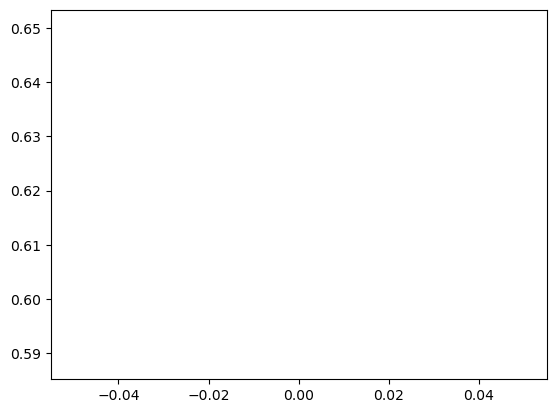

In [11]:

print(np.mean(plaq_samp))
print(np.std(plaq_samp))
plt.plot(plaq_samp)

(0.0008520367790162974-1.6593526212047037e-40j)
8.761587034348171e-05


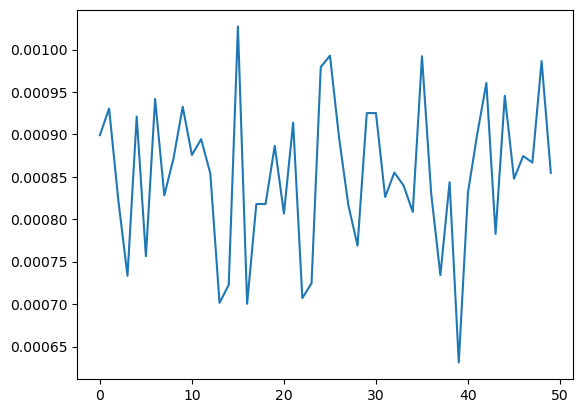

In [18]:
print(np.mean(wf_energyHMC))
print(np.std(wf_energyHMC))
plt.plot(wf_energyHMC)

In [9]:
#W = g.copy(U)

def MC_Ham(U):
    return action_gauge(U)


# these masks still need work....

def gauge_force_coord_update(block_size = int(size/2)): # check that I didn't screw these up
    #g.message("Compute gauge force") #####################

    V = action_gauge.gradient(U, U)
    V = [g.cshift(V[0], 0, block_size), g.cshift(V[1], 0, block_size)]

    V[1][0, :] = 0. # cut torus twice 
    V[1][block_size, :] = 0.

    V[0][block_size:, :] = 0. # zero momenta links so that they're not updated
    V[1][block_size:, :] = 0.
    
    x = log(lambda: V , "gauge")()
    
    return x

def gauge_force_mom_update(block_size = int(size/2)):

    V = action_gauge.gradient(U, U)
    V = [g.cshift(V[0], 0, block_size), g.cshift(V[1], 0, block_size)]

    V[1][0, :] = 0. # cut torus twice 
    V[1][block_size, :] = 0.

    V[0][:block_size, :] = 0. # zero momenta links so that they're not updated
    V[1][:block_size, :] = 0.
    
    x = log(lambda: V , "gauge")()

    return x
    

iq_1 = sympl.update_q(
    U, log(lambda: gauge_force_coord_update(), "gauge_force_coord_update")
)

iq_2 = sympl.update_p(
    U, log(lambda: gauge_force_mom_update(), "gauge_force_mom_update")
)

# integrator
mdintMC = sympl.leap_frog(50, iq_1, iq_2)

#g.message(f"Integration scheme:\n{mdint}")

In [10]:
########################
# test update leaves half of the lattice invariant
########################

V = g.copy(W)

#V[1][0, :] = 1. # cut torus twice
#V[1][5, :] = 1.

V[0][:5, :] = 1. # zero coord links to measure just the action from the momenta part of the latice
V[1][:5, :] = 1. # zero coord links 

#V[0][5:, :] = 1. # zero momenta links so that they're not updated
#V[1][5:, :] = 1.

a = V[1][0, 9]

print("before coord update = ", action_gauge(V))


# in the course of the update the coord links will be updated and I'll have to set them back to one to be sure to measure just the momenta
# part again
iq_test = sympl.update_p(
    V, log(lambda: gauge_force_coord_update(), "gauge_force_coord_update") 
)

iq_test(1)

V[0][:5, :] = 1. # zero coord links to make sure momenta bit is invariant
V[1][:5, :] = 1. # zero coord links

print("after coord update = ", action_gauge(V))
print("frozen link difference = ", V[1][0, 9] - a)


V = g.copy(W)

V[0][5:, :] = 1. # zero momenta links so that they're not updated
V[1][5:, :] = 1.

a = V[1][0, 9]

print("before mom update = ", action_gauge(V))


# in the course of the update the coord links will be updated and I'll have to set them back to one to be sure to measure just the momenta
# part again
iq_test = sympl.update_p(
    V, log(lambda: gauge_force_mom_update(), "gauge_force_coord_update") 
)

iq_test(1)

V[0][5:, :] = 1. # zero coord links to make sure momenta bit is invariant
V[1][5:, :] = 1. # zero coord links

print("after mom update = ", action_gauge(V))
print("frozen link difference = ", V[1][0, 9] - a)

NameError: name 'W' is not defined

In [13]:
energies1 = [MC_Ham(U)]

for i in range(20):
    mdintMC(tau)
    energies1.append(MC_Ham(U))


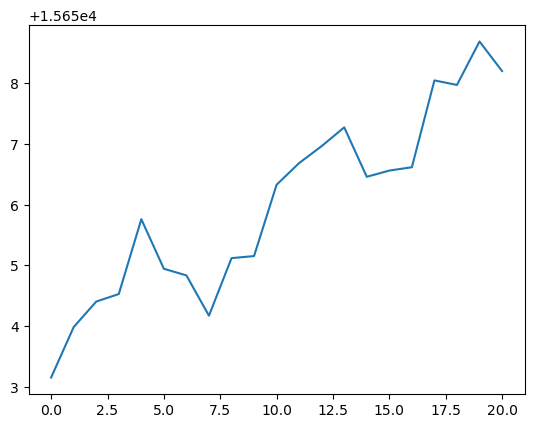

In [14]:
plt.plot(energies1)

In [18]:
dwfeMC2 = []
dwfeHMC2 = []
eps = 0.05
tau1 = tau*0.5
for j in range(20):
    for i in range(1):
        U_wf = g.copy(U)
                    
        for l in range(320): # t = 16
            U_wf = g.qcd.gauge.smear.wilson_flow(U_wf, epsilon=eps)
            
        Ei = g.qcd.gauge.energy_density(U_wf)
        
        
        mdintMC(tau1)
        #hmc(tau, mom)
        tau1*= 1.2
        
        U_wf = g.copy(U)
                    
        for l in range(320): # t = 16
            U_wf = g.qcd.gauge.smear.wilson_flow(U_wf, epsilon=eps)
            
        Ef = g.qcd.gauge.energy_density(U_wf)
        
        dwfeMC2.append(Ef - Ei)
        print("traj = ", j, "delta E  ", dwfeMC2[-1])

    
    for i in range(1):
        U_wf = g.copy(U)
                    
        for l in range(320): # t = 16
            U_wf = g.qcd.gauge.smear.wilson_flow(U_wf, epsilon=eps)
            
        Ei = g.qcd.gauge.energy_density(U_wf)
        
        
        #mdintMC(tau1)
        hmc(tau, mom)
    
        U_wf = g.copy(U)
                    
        for l in range(320): # t = 16
            U_wf = g.qcd.gauge.smear.wilson_flow(U_wf, epsilon=eps)
            
        Ef = g.qcd.gauge.energy_density(U_wf)
        
        dwfeHMC2.append(Ef - Ei)
    
        print("traj = ", j, "delta  ", dwfeHMC2[-1])


traj =  0 delta E   (2.7508930355142082e-05+1.1795121537791996e-39j)
traj =  0 delta   0j
traj =  1 delta E   (-2.756880818285273e-05+7.63382561813302e-40j)
traj =  1 delta   (-0.00018890965456378795+5.337938214183239e-40j)
traj =  2 delta E   (3.8589260691433724e-05-3.6734198463196485e-40j)
traj =  2 delta   (0.00012790034751308278-1.4349296274686127e-40j)
traj =  3 delta E   (-7.525547449112357e-05+4.0178029569121155e-40j)
traj =  3 delta   0j


KeyboardInterrupt: 

In [ ]:
plt(dwfeMC2)

In [17]:
M = [abs(x) for x in dwfeMC2]
print("MC", np.mean(np.asarray(M)), np.std(np.asarray(M)))

M = [abs(x) for x in dwfeHMC2]
print("HMC", np.mean(np.asarray(M)), np.std(np.asarray(M)))


MC 0.00011087913375000674 9.341064588139881e-05
HMC 0.00010639898616652028 8.890659245560002e-05


In [ ]:
M = [abs(x) for x in dwfeMC2]
print("MC", np.mean(np.asarray(M)), np.std(np.asarray(M)))

M = [abs(x) for x in dwfeHMC2]
print("HMC", np.mean(np.asarray(M)), np.std(np.asarray(M)))


In [20]:
# production
history = []
plaqMC = []
wf_energy = []

tau1 = tau*0.5

start = time.time()

ff = 0
for i in range(10):
    for j in range(1):
        history += [hmc(tau, mom)]
        ff += 1
    print("hmc ", g.qcd.gauge.plaquette(U))

    # should mix these in more because swapping directions almost undoes 90 percent of the work
    for k in range(9):
        ff += 1
        en1 = MC_Ham(U)
        V = g.copy(U) # should give wrong asnwer though unless I randomly choose t direction
        if np.random.randint(0,2) == 0:
            tau1 *= -1 # I am just going back and forth!!!
        mdintMC(tau1)
        en2 = MC_Ham(U)
        print("MC ", g.qcd.gauge.plaquette(U))
        if np.exp(- (en2 - en1)) < np.random.uniform(0,1):
            #U[:] @= V[:]
            U[0] @= V[0]
            U[1] @= V[1]
            print("REJECT", "DELTA S = ", en2 - en1 )
        
        if ff % 2 == 0:
            t = 0.0
            eps = 0.05
            U_wf = g.copy(U)
            
            for l in range(320): # t = 8
                U_wf = g.qcd.gauge.smear.wilson_flow(U_wf, epsilon=eps)
    
            E = g.qcd.gauge.energy_density(U_wf)
            wf_energy.append(E)
    
    P = g.qcd.gauge.plaquette(U)
    plaqMC.append(P) 
    
    g.message(f"Trajectory {i}, P={P}")
    #if i % nwrite == 0:
    #    g.save(f"ckpoint_lat.{seed}.{i}", U, g.format.nersc())


end = time.time()
print("time taken = ", end - start)

history = np.array(history)
g.message(f"Acceptance rate = {np.mean(history[:,0]):.2f}")
g.message(f"<|dH|> = {np.mean(np.abs(history[:,1])):.4e}")

hmc  0.6205885276193673
MC  0.6205854478644204
MC  0.6205885276193603
MC  0.6205926043699506
MC  0.6205986396742977
MC  0.6205926043699437
MC  0.6205986396742907
MC  0.6205892657825727
MC  0.620598639674284
MC  0.6205892657825657
GPT :     689.175340 s : Trajectory 0, P=0.6205892657825657
hmc  0.6194502910111447
MC  0.6194502088704802
MC  0.619452532469261
MC  0.6194502088704733
MC  0.6194502910111309
MC  0.6194502088704663
MC  0.619452532469247
MC  0.6194486326696841
MC  0.6194525324692401
MC  0.6194502088704524
GPT :     728.544769 s : Trajectory 1, P=0.6194502088704524
hmc  0.6185654310988362
MC  0.6185593034294534
REJECT DELTA S =  0.2509893379192363
MC  0.6185589455840712
MC  0.6185594496834002
MC  0.6185589455840643
MC  0.6185654310988223
MC  0.6185593034294394
MC  0.6185654310988155
MC  0.6185593034294325
MC  0.6185654310988085
GPT :     767.979203 s : Trajectory 2, P=0.6185654310988085
hmc  0.6143453965247211
MC  0.6143455561600145
MC  0.6143453965247141
MC  0.6143455561600075


10
0.615978223588054
0.0028702249365384703


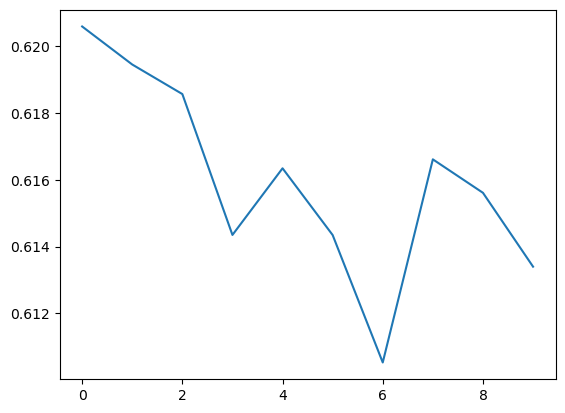

In [22]:
print(len(plaqMC))
print(np.mean(plaqMC))
print(np.std(plaqMC))

plt.plot(plaqMC)

#0.6182843801630405
#0.0018838648675919768

In [26]:
print(len(plaq[0:-1:10]))
print(len(plaq_samp))

10
10


(0.0008500715814509259+1.1879782385812645e-40j)
7.179945409193131e-05


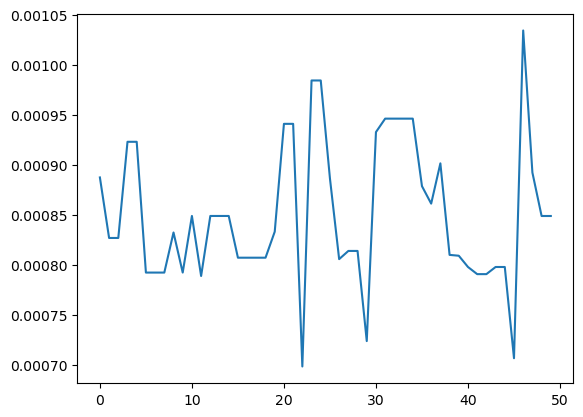

In [27]:
print(np.mean(wf_energy))
print(np.std(wf_energy))
plt.plot(wf_energy)

#(0.0030426871200031885+9.885789940980357e-40j)
#0.00012500012015086935

In [30]:
wf_energy

[np.complex128(0.0008872313025100398-5.022253696140144e-40j),
 np.complex128(0.0008267279846214287+1.2254299018581952e-39j),
 np.complex128(0.0008267279846214271+6.715470656553107e-40j),
 np.complex128(0.0009228670228665051-5.883211472621312e-40j),
 np.complex128(0.0009228670228665082+1.259868212917442e-39j),
 np.complex128(0.000792131530388456-9.126152430700377e-40j),
 np.complex128(0.0007921315303884589-1.4349296274686127e-41j),
 np.complex128(0.0007921315303884551-4.591774807899561e-41j),
 np.complex128(0.0008322018018597889+4.1325973271096045e-40j),
 np.complex128(0.0007921315303884696-5.165746658887006e-40j),
 np.complex128(0.0008487201447109185+6.801566434201224e-40j),
 np.complex128(0.0007887248747292854+1.8941071082585687e-39j),
 np.complex128(0.0008487201447109317-3.4553105429444193e-39j),
 np.complex128(0.0008487201447109255+2.1552643004578562e-39j),
 np.complex128(0.0008487201447109201-5.911910065170684e-40j),
 np.complex128(0.0008070004241501514-7.461634062836786e-41j),
 np

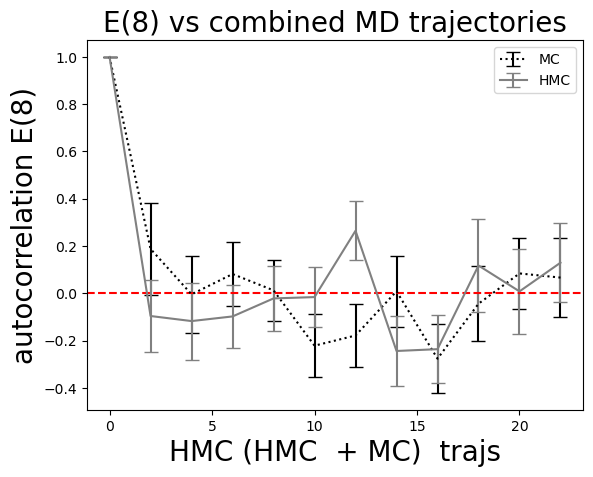

In [29]:
MC = autocorrelation2(wf_energy, 1, 12, 1)
HMC = autocorrelation2(wf_energyHMC, 1, 12, 1)


plt.title("E(8) vs combined MD trajectories", size=20 )
plt.ylabel("autocorrelation E(16)", size=20)
plt.xlabel("HMC (HMC  + MC)  trajs",size=20)
plt.errorbar(np.arange(len(MC[0]))*2, MC[0], MC[1], color='black', label='MC', capsize=5, linestyle=':') # MC
plt.errorbar(np.arange(len(HMC[0]))*2, HMC[0], HMC[1], color= 'grey', label="HMC", capsize=5) #HMC
plt.axhline(y=0, color='red', linestyle='--')
plt.legend()
#plt.savefig("2D_100_E16_AC.pdf")

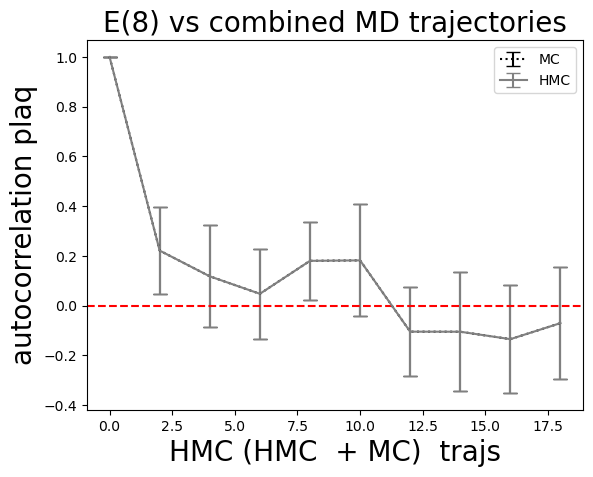

In [95]:
MC = autocorrelation2(plaq[0:-1:10], 1, 10, 1)
HMC = autocorrelation2(plaq_samp, 1, 10, 1)

plt.title("E(8) vs combined MD trajectories", size=20 )
plt.ylabel("autocorrelation plaq", size=20)
plt.xlabel("HMC (HMC  + MC)  trajs",size=20)
plt.errorbar(np.arange(len(MC[0]))*2, MC[0], MC[1], color='black', label='MC', capsize=5, linestyle=':') # MC
plt.errorbar(np.arange(len(HMC[0]))*2, HMC[0], HMC[1], color= 'grey', label="HMC", capsize=5) #HMC
plt.axhline(y=0, color='red', linestyle='--')
plt.savefig("2D_200_plaq_AC.pdf")
plt.legend()